# Data Visualization - Satellite Water Body Semantic Segmentation

## Comprehensive Visual Analysis
This notebook provides comprehensive visualizations of the satellite water body semantic segmentation dataset.

## 1. Import Libraries and Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Define paths
base_path = Path('../data')
train_images_path = base_path / 'train_images'
train_masks_path = base_path / 'train_masks'
valid_images_path = base_path / 'valid_images'
valid_masks_path = base_path / 'valid_masks'

# Create results folder
results_dir = Path('../results')
results_dir.mkdir(exist_ok=True)
print(f"Results folder: {results_dir.resolve()}")

print("Libraries loaded and paths configured!")

Libraries loaded and paths configured!


In [2]:
# Load file lists
train_images = sorted(os.listdir(train_images_path))
train_masks = sorted(os.listdir(train_masks_path))
valid_images = sorted(os.listdir(valid_images_path))
valid_masks = sorted(os.listdir(valid_masks_path))

print(f"Train set: {len(train_images)} images")
print(f"Validation set: {len(valid_images)} images")

Train set: 2683 images
Validation set: 158 images


In [3]:
def load_image_and_mask(img_path, mask_path):
    """Load image and mask pair"""
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask_binary = (mask > 127).astype(np.uint8)
    
    return image, mask_binary

def get_image_properties(image_path):
    """Extract image properties"""
    img = Image.open(image_path)
    img_array = np.array(img)
    return {
        'width': img.width,
        'height': img.height,
        'channels': len(img_array.shape) if len(img_array.shape) == 3 else 1
    }

def calculate_mask_statistics(mask_array):
    """Calculate mask statistics"""
    total_pixels = mask_array.size
    water_pixels = np.sum(mask_array)
    return {
        'water_percentage': (water_pixels / total_pixels) * 100,
        'water_pixels': water_pixels,
        'background_pixels': total_pixels - water_pixels
    }

print("Helper functions defined!")

Helper functions defined!


## 2. Dataset Scale Visualization

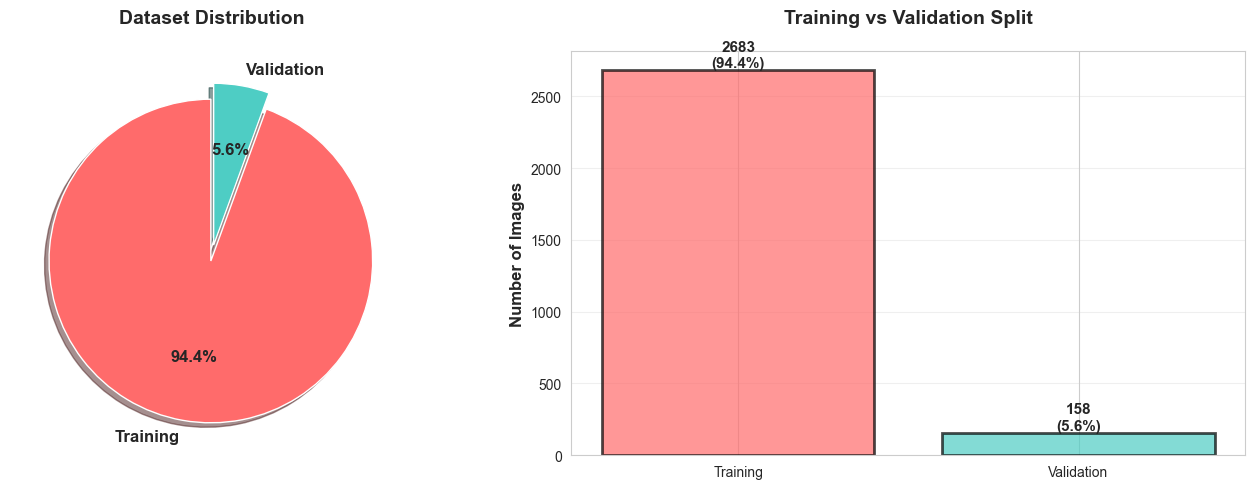


  Dataset Distribution:
  Training: 2,683 images
  Validation: 158 images
  Total: 2,841 images


In [ ]:
# Create dataset overview visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dataset split pie chart
datasets = ['Training', 'Validation']
sizes = [len(train_images), len(valid_images)]
colors = ['#FF6B6B', '#4ECDC4']
explode = (0.05, 0.05)

axes[0].pie(sizes, explode=explode, labels=datasets, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Dataset Distribution', fontsize=14, weight='bold', pad=20)

# Bar chart with counts
bars = axes[1].bar(datasets, sizes, color=colors, edgecolor='black', linewidth=2, alpha=0.7)
axes[1].set_ylabel('Number of Images', fontsize=12, weight='bold')
axes[1].set_title('Training vs Validation Split', fontsize=14, weight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(size)}\n({size/(len(train_images)+len(valid_images))*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig(results_dir / '01_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n  Dataset Distribution:")
print(f"  Training: {len(train_images):,} images")
print(f"  Validation: {len(valid_images):,} images")
print(f"  Total: {len(train_images) + len(valid_images):,} images")

## 3. Image Properties Visualization

In [7]:
# Sample images to analyze properties (to save computation time)
np.random.seed(42)
sample_size = 150
train_sample_indices = np.random.choice(len(train_images), min(sample_size, len(train_images)), replace=False)
valid_sample_indices = np.arange(len(valid_images))

image_props_list = []

# Collect training image properties
print("Analyzing training image properties...")
for idx in train_sample_indices:
    props = get_image_properties(train_images_path / train_images[idx])
    props['dataset'] = 'Training'
    image_props_list.append(props)

# Collect validation image properties
print("Analyzing validation image properties...")
for idx in valid_sample_indices:
    props = get_image_properties(valid_images_path / valid_images[idx])
    props['dataset'] = 'Validation'
    image_props_list.append(props)

props_df = pd.DataFrame(image_props_list)
print(f"✓ Analyzed {len(props_df)} images")

Analyzing training image properties...
Analyzing validation image properties...
✓ Analyzed 308 images


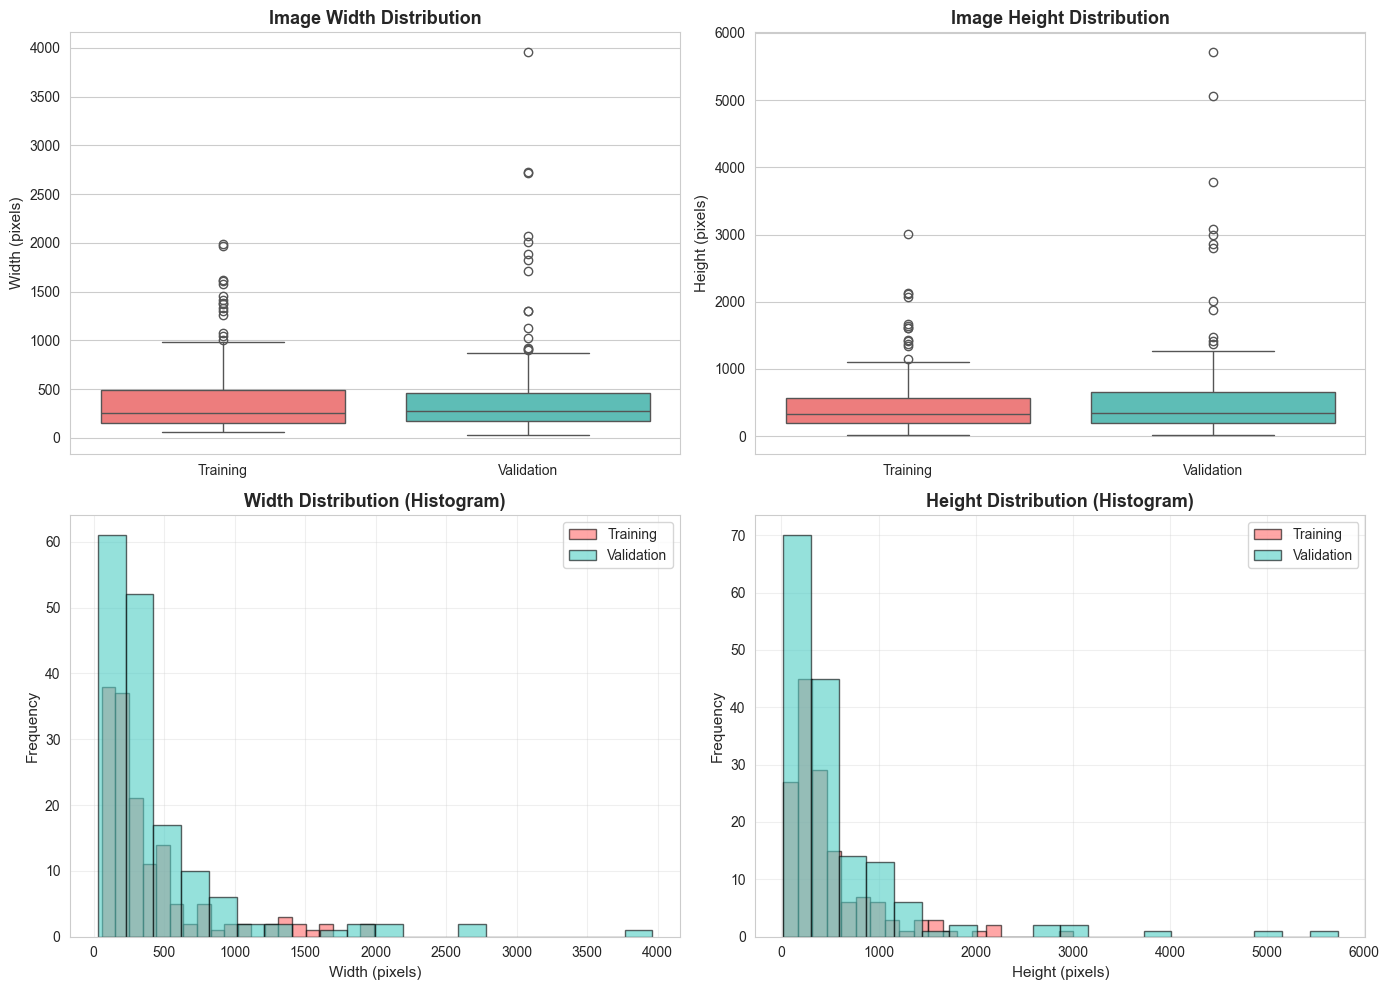


  Image Dimensions Summary:
  Average size: 422 × 547 pixels
  Min size: 31×18
  Max size: 3962×5724


In [ ]:
# Visualize image dimensions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Width distribution
for dataset in ['Training', 'Validation']:
    subset = props_df[props_df['dataset'] == dataset]
axes = axes.flatten()

# Width by dataset
sns.boxplot(data=props_df, x='dataset', y='width', ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Image Width Distribution', fontsize=13, weight='bold')
axes[0].set_ylabel('Width (pixels)', fontsize=11)
axes[0].set_xlabel('')

# Height by dataset
sns.boxplot(data=props_df, x='dataset', y='height', ax=axes[1], palette=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Image Height Distribution', fontsize=13, weight='bold')
axes[1].set_ylabel('Height (pixels)', fontsize=11)
axes[1].set_xlabel('')

# Width histogram
for dataset, color in [('Training', '#FF6B6B'), ('Validation', '#4ECDC4')]:
    subset = props_df[props_df['dataset'] == dataset]['width']
    axes[2].hist(subset, bins=20, alpha=0.6, label=dataset, color=color, edgecolor='black')
axes[2].set_title('Width Distribution (Histogram)', fontsize=13, weight='bold')
axes[2].set_xlabel('Width (pixels)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].legend()
axes[2].grid(alpha=0.3)

# Height histogram
for dataset, color in [('Training', '#FF6B6B'), ('Validation', '#4ECDC4')]:
    subset = props_df[props_df['dataset'] == dataset]['height']
    axes[3].hist(subset, bins=20, alpha=0.6, label=dataset, color=color, edgecolor='black')
axes[3].set_title('Height Distribution (Histogram)', fontsize=13, weight='bold')
axes[3].set_xlabel('Height (pixels)', fontsize=11)
axes[3].set_ylabel('Frequency', fontsize=11)
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / '02_image_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n  Image Dimensions Summary:")
print(f"  Average size: {props_df['width'].mean():.0f} × {props_df['height'].mean():.0f} pixels")
print(f"  Min size: {props_df['width'].min()}×{props_df['height'].min()}")
print(f"  Max size: {props_df['width'].max()}×{props_df['height'].max()}")

## 4. Sample Images Visualization

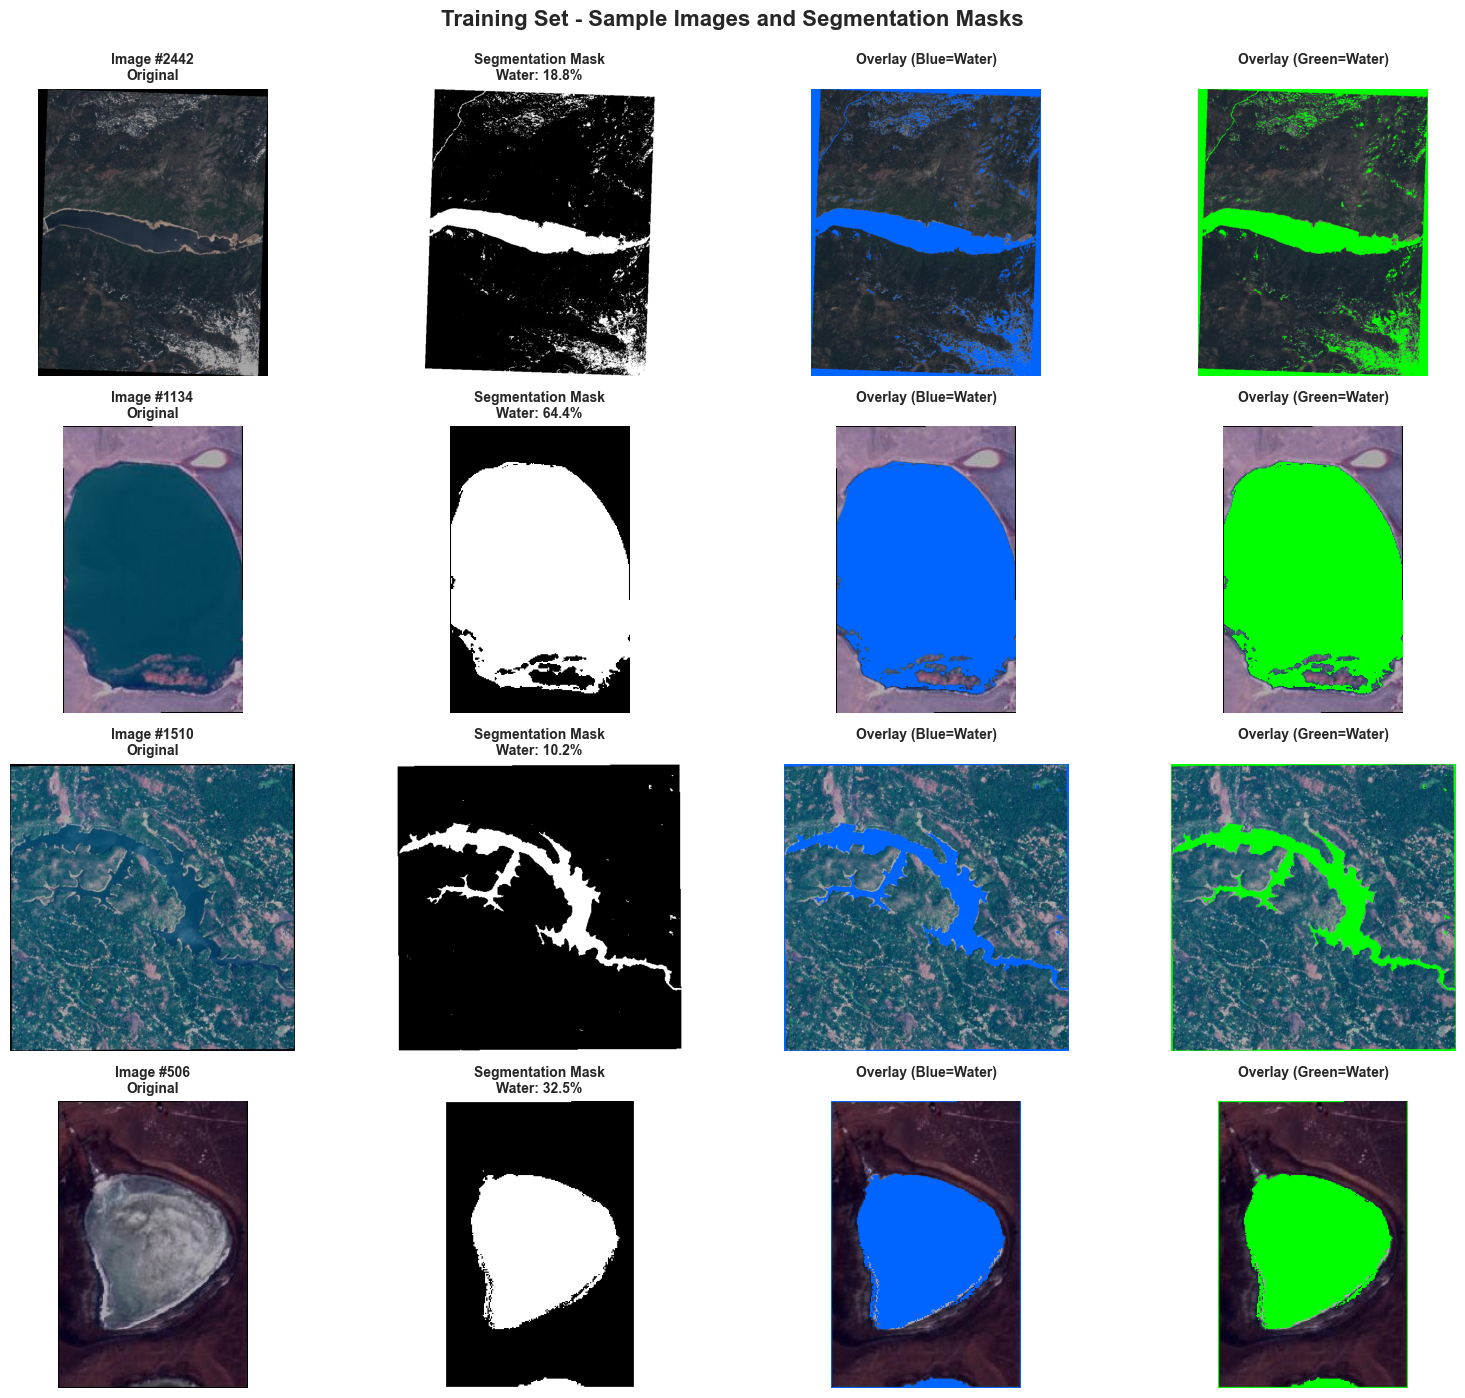

 Training samples visualized


In [ ]:
# Visualize sample images with their segmentation masks
# Training set samples
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle('Training Set - Sample Images and Segmentation Masks', fontsize=16, weight='bold', y=0.995)

np.random.seed(42)
sample_idx = np.random.choice(len(train_images), 4, replace=False)

for row_idx, file_idx in enumerate(sample_idx):
    # Load image and mask
    image, mask = load_image_and_mask(
        train_images_path / train_images[file_idx],
        train_masks_path / train_masks[file_idx]
    )
    
    # Calculate statistics
    stats = calculate_mask_statistics(mask)
    water_pct = stats['water_percentage']
    
    # Original image
    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(f'Image #{file_idx}\nOriginal', fontsize=10, weight='bold')
    axes[row_idx, 0].axis('off')
    
    # Mask
    axes[row_idx, 1].imshow(mask, cmap='gray')
    axes[row_idx, 1].set_title(f'Segmentation Mask\nWater: {water_pct:.1f}%', fontsize=10, weight='bold')
    axes[row_idx, 1].axis('off')
    
    # Overlay - Water bodies in blue
    overlay = image.copy().astype(float)
    overlay[mask == 1] = [0, 100, 255]
    axes[row_idx, 2].imshow(overlay.astype(np.uint8))
    axes[row_idx, 2].set_title(f'Overlay (Blue=Water)\n', fontsize=10, weight='bold')
    axes[row_idx, 2].axis('off')
    
    # RGB composite - for visualization
    rgb_overlay = image.copy()
    rgb_overlay[mask == 1] = [0, 255, 0]
    axes[row_idx, 3].imshow(rgb_overlay)
    axes[row_idx, 3].set_title(f'Overlay (Green=Water)\n', fontsize=10, weight='bold')
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.savefig(results_dir / '03_training_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Training samples visualized")

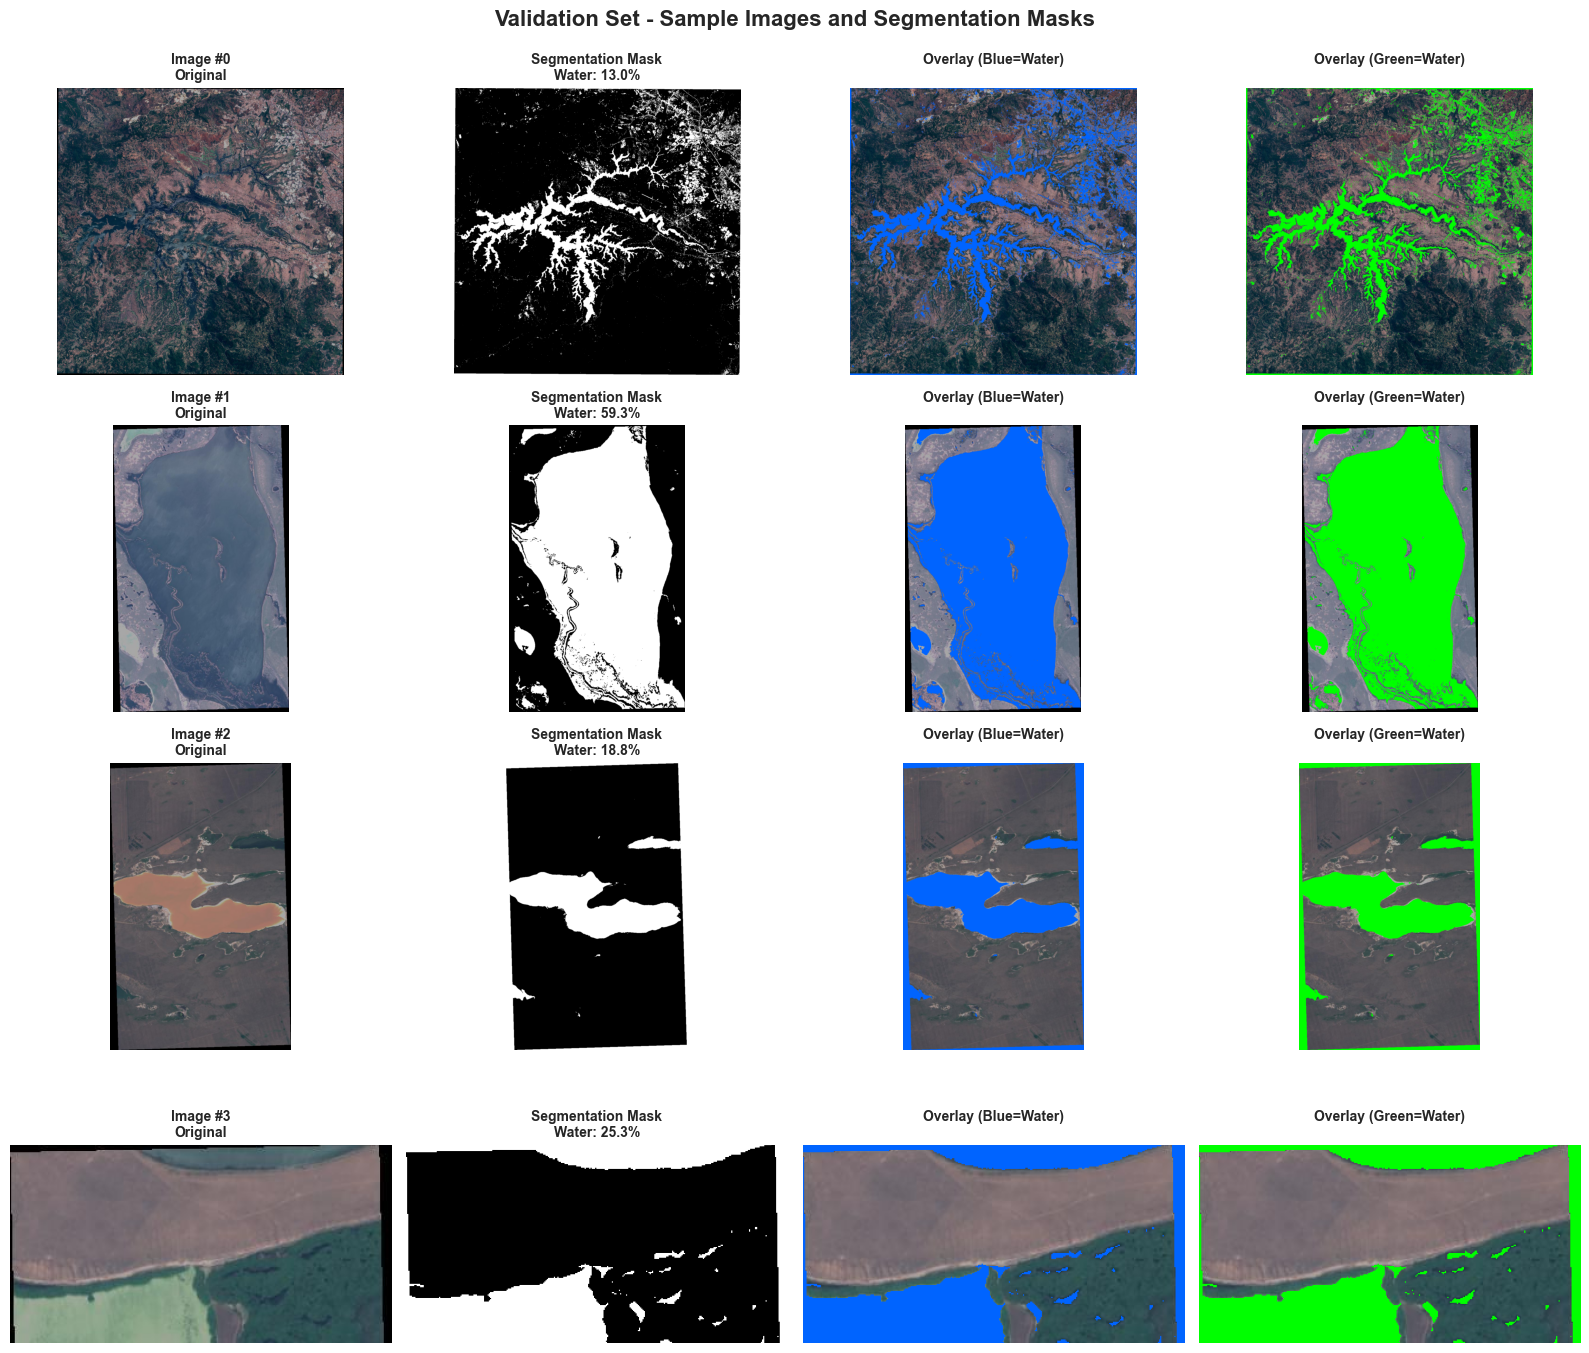

 Validation samples visualized


In [ ]:
# Visualize validation set samples
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle('Validation Set - Sample Images and Segmentation Masks', fontsize=16, weight='bold', y=0.995)

# Use all validation images if they fit, otherwise sample
val_indices = list(range(min(4, len(valid_images))))

for row_idx, file_idx in enumerate(val_indices):
    # Load image and mask
    image, mask = load_image_and_mask(
        valid_images_path / valid_images[file_idx],
        valid_masks_path / valid_masks[file_idx]
    )
    
    # Calculate statistics
    stats = calculate_mask_statistics(mask)
    water_pct = stats['water_percentage']
    
    # Original image
    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(f'Image #{file_idx}\nOriginal', fontsize=10, weight='bold')
    axes[row_idx, 0].axis('off')
    
    # Mask
    axes[row_idx, 1].imshow(mask, cmap='gray')
    axes[row_idx, 1].set_title(f'Segmentation Mask\nWater: {water_pct:.1f}%', fontsize=10, weight='bold')
    axes[row_idx, 1].axis('off')
    
    # Overlay - Water bodies in blue
    overlay = image.copy().astype(float)
    overlay[mask == 1] = [0, 100, 255]
    axes[row_idx, 2].imshow(overlay.astype(np.uint8))
    axes[row_idx, 2].set_title(f'Overlay (Blue=Water)\n', fontsize=10, weight='bold')
    axes[row_idx, 2].axis('off')
    
    # RGB composite
    rgb_overlay = image.copy()
    rgb_overlay[mask == 1] = [0, 255, 0]
    axes[row_idx, 3].imshow(rgb_overlay)
    axes[row_idx, 3].set_title(f'Overlay (Green=Water)\n', fontsize=10, weight='bold')
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.savefig(results_dir / '04_validation_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Validation samples visualized")

## 5. Water Body Coverage Analysis

In [16]:
# Collect mask statistics for both training and validation sets
mask_stats_list = []

print("Analyzing training masks...")
for idx in train_sample_indices:
    mask_path = train_masks_path / train_masks[idx]
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask_binary = (mask > 127).astype(np.uint8)
    stats = calculate_mask_statistics(mask_binary)
    stats['dataset'] = 'Training'
    mask_stats_list.append(stats)

print("Analyzing validation masks...")
for idx in valid_sample_indices:
    mask_path = valid_masks_path / valid_masks[idx]
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask_binary = (mask > 127).astype(np.uint8)
    stats = calculate_mask_statistics(mask_binary)
    stats['dataset'] = 'Validation'
    mask_stats_list.append(stats)

mask_stats_df = pd.DataFrame(mask_stats_list)
print(f"Analyzed {len(mask_stats_df)} masks")

Analyzing training masks...
Analyzing validation masks...
Analyzed 308 masks


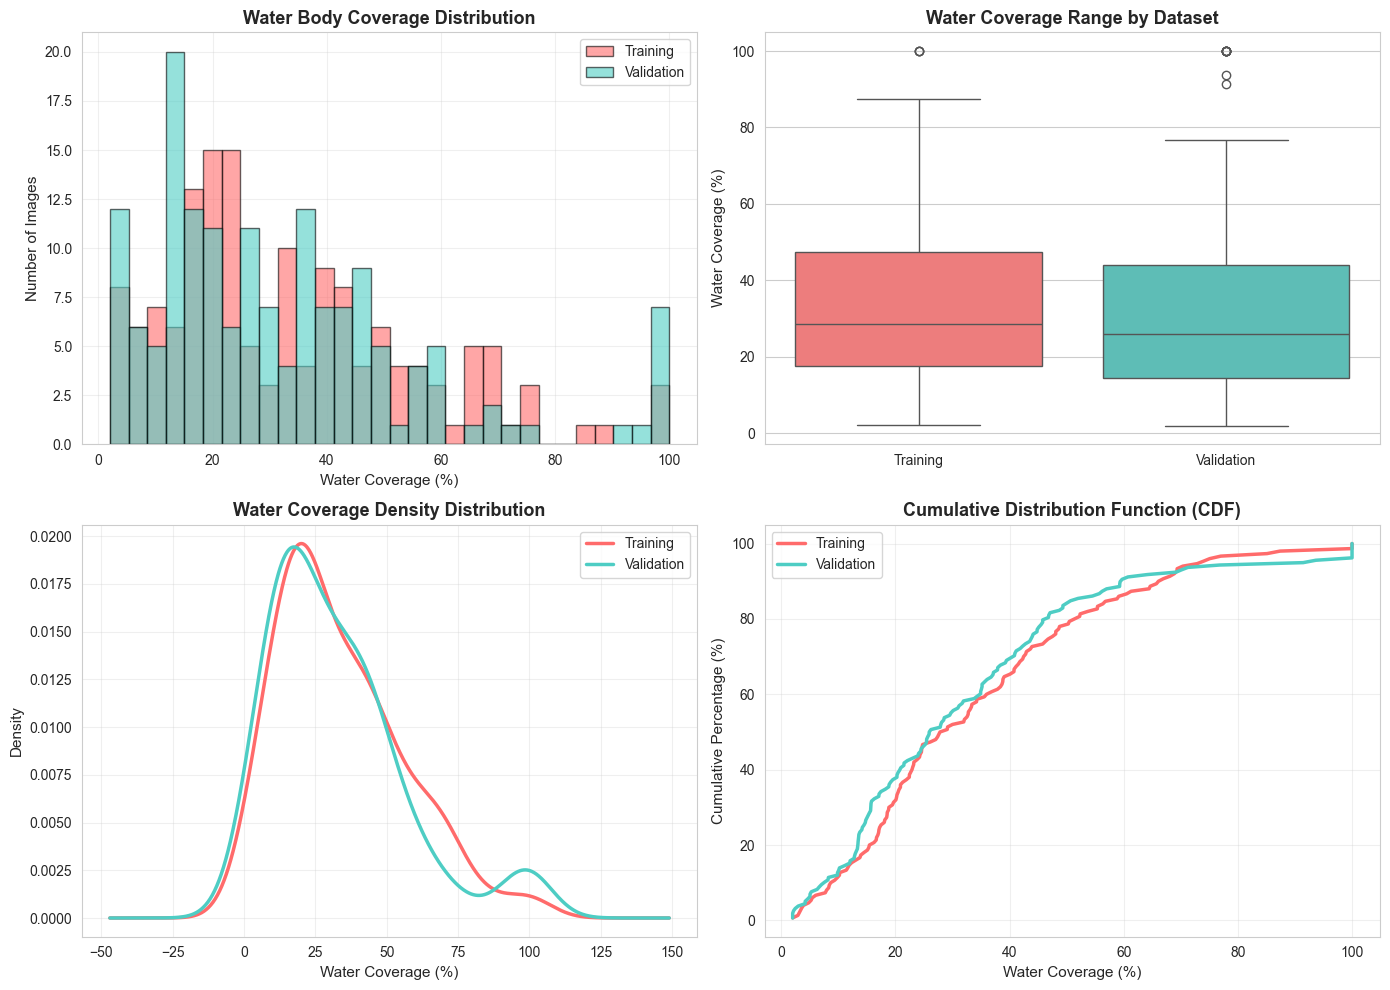

Water coverage distribution visualized


In [ ]:
# Water coverage distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram - Water percentage distribution
for dataset, color in [('Training', '#FF6B6B'), ('Validation', '#4ECDC4')]:
    subset = mask_stats_df[mask_stats_df['dataset'] == dataset]['water_percentage']
    axes[0, 0].hist(subset, bins=30, alpha=0.6, label=dataset, color=color, edgecolor='black')

axes[0, 0].set_title('Water Body Coverage Distribution', fontsize=13, weight='bold')
axes[0, 0].set_xlabel('Water Coverage (%)', fontsize=11)
axes[0, 0].set_ylabel('Number of Images', fontsize=11)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# Box plot - Water percentage by dataset
sns.boxplot(data=mask_stats_df, x='dataset', y='water_percentage', ax=axes[0, 1],
           palette=['#FF6B6B', '#4ECDC4'])
axes[0, 1].set_title('Water Coverage Range by Dataset', fontsize=13, weight='bold')
axes[0, 1].set_ylabel('Water Coverage (%)', fontsize=11)
axes[0, 1].set_xlabel('')

# Density plot
for dataset, color in [('Training', '#FF6B6B'), ('Validation', '#4ECDC4')]:
    subset = mask_stats_df[mask_stats_df['dataset'] == dataset]['water_percentage']
    subset.plot(kind='density', ax=axes[1, 0], color=color, linewidth=2.5, label=dataset)

axes[1, 0].set_title('Water Coverage Density Distribution', fontsize=13, weight='bold')
axes[1, 0].set_xlabel('Water Coverage (%)', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Cumulative distribution
for dataset, color in [('Training', '#FF6B6B'), ('Validation', '#4ECDC4')]:
    subset = mask_stats_df[mask_stats_df['dataset'] == dataset]['water_percentage'].sort_values()
    y = np.arange(1, len(subset) + 1) / len(subset) * 100
    axes[1, 1].plot(subset.values, y, label=dataset, color=color, linewidth=2.5)

axes[1, 1].set_title('Cumulative Distribution Function (CDF)', fontsize=13, weight='bold')
axes[1, 1].set_xlabel('Water Coverage (%)', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Percentage (%)', fontsize=11)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / '05_water_coverage_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Water coverage distribution visualized")

## 6. Class Imbalance Analysis

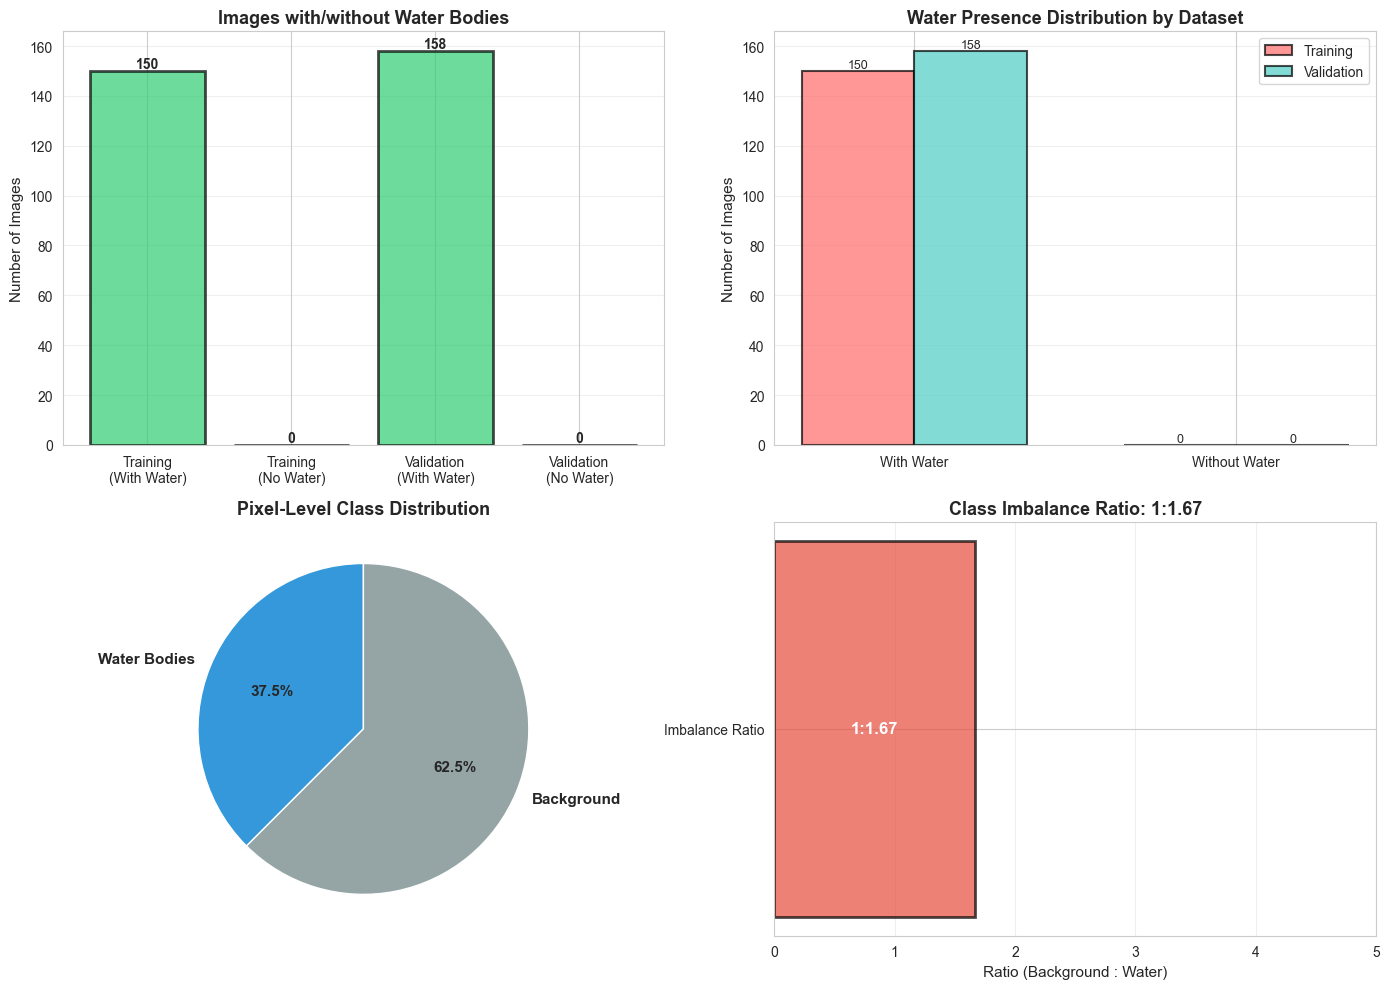


  Class Imbalance Analysis:
  Training - With Water: 150, Without: 0
  Validation - With Water: 158, Without: 0
  Pixel-level Imbalance Ratio: 1:1.67


In [ ]:
# Calculate class-level statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Images with/without water bodies
has_water_train = (mask_stats_df[mask_stats_df['dataset'] == 'Training']['water_pixels'] > 0).sum()
no_water_train = len(mask_stats_df[mask_stats_df['dataset'] == 'Training']) - has_water_train

has_water_val = (mask_stats_df[mask_stats_df['dataset'] == 'Validation']['water_pixels'] > 0).sum()
no_water_val = len(mask_stats_df[mask_stats_df['dataset'] == 'Validation']) - has_water_val

categories = ['Training\n(With Water)', 'Training\n(No Water)', 'Validation\n(With Water)', 'Validation\n(No Water)']
values = [has_water_train, no_water_train, has_water_val, no_water_val]
colors_bar = ['#2ECC71', '#E74C3C', '#2ECC71', '#E74C3C']

bars = axes[0, 0].bar(categories, values, color=colors_bar, edgecolor='black', linewidth=2, alpha=0.7)
axes[0, 0].set_title('Images with/without Water Bodies', fontsize=13, weight='bold')
axes[0, 0].set_ylabel('Number of Images', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, values):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(val)}',
                   ha='center', va='bottom', fontsize=10, weight='bold')

# 2. Stacked bar chart by dataset
train_data = [has_water_train, no_water_train]
val_data = [has_water_val, no_water_val]

x_pos = np.arange(2)
width = 0.35

bars1 = axes[0, 1].bar(x_pos - width/2, train_data, width, label='Training', color='#FF6B6B', edgecolor='black', linewidth=1.5, alpha=0.7)
bars2 = axes[0, 1].bar(x_pos + width/2, val_data, width, label='Validation', color='#4ECDC4', edgecolor='black', linewidth=1.5, alpha=0.7)

axes[0, 1].set_ylabel('Number of Images', fontsize=11)
axes[0, 1].set_title('Water Presence Distribution by Dataset', fontsize=13, weight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(['With Water', 'Without Water'])
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontsize=9)

# 3. Pixel-level imbalance
total_water_pixels = mask_stats_df['water_pixels'].sum()
total_bg_pixels = mask_stats_df['background_pixels'].sum()
total_px = total_water_pixels + total_bg_pixels

classes = ['Water Bodies', 'Background']
class_sizes = [total_water_pixels, total_bg_pixels]
class_colors = ['#3498DB', '#95A5A6']

wedges, texts, autotexts = axes[1, 0].pie(class_sizes, labels=classes, autopct='%1.1f%%',
                                           colors=class_colors, startangle=90,
                                           textprops={'fontsize': 11, 'weight': 'bold'})
axes[1, 0].set_title('Pixel-Level Class Distribution', fontsize=13, weight='bold')

# 4. Class imbalance ratio visualization
imbalance_ratio = total_bg_pixels / total_water_pixels if total_water_pixels > 0 else 0

axes[1, 1].barh(['Imbalance Ratio'], [imbalance_ratio], color='#E74C3C', edgecolor='black', linewidth=2, alpha=0.7, height=0.5)
axes[1, 1].set_xlabel('Ratio (Background : Water)', fontsize=11)
axes[1, 1].set_title(f'Class Imbalance Ratio: 1:{imbalance_ratio:.2f}', fontsize=13, weight='bold')
axes[1, 1].set_xlim(0, max(imbalance_ratio * 1.2, 5))
axes[1, 1].grid(axis='x', alpha=0.3)

axes[1, 1].text(imbalance_ratio/2, 0, f'1:{imbalance_ratio:.2f}', 
                ha='center', va='center', fontsize=12, weight='bold', color='white')

plt.tight_layout()
plt.savefig(results_dir / '06_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n  Class Imbalance Analysis:")
print(f"  Training - With Water: {has_water_train}, Without: {no_water_train}")
print(f"  Validation - With Water: {has_water_val}, Without: {no_water_val}")
print(f"  Pixel-level Imbalance Ratio: 1:{imbalance_ratio:.2f}")

## 7. Statistical Summary Visualization

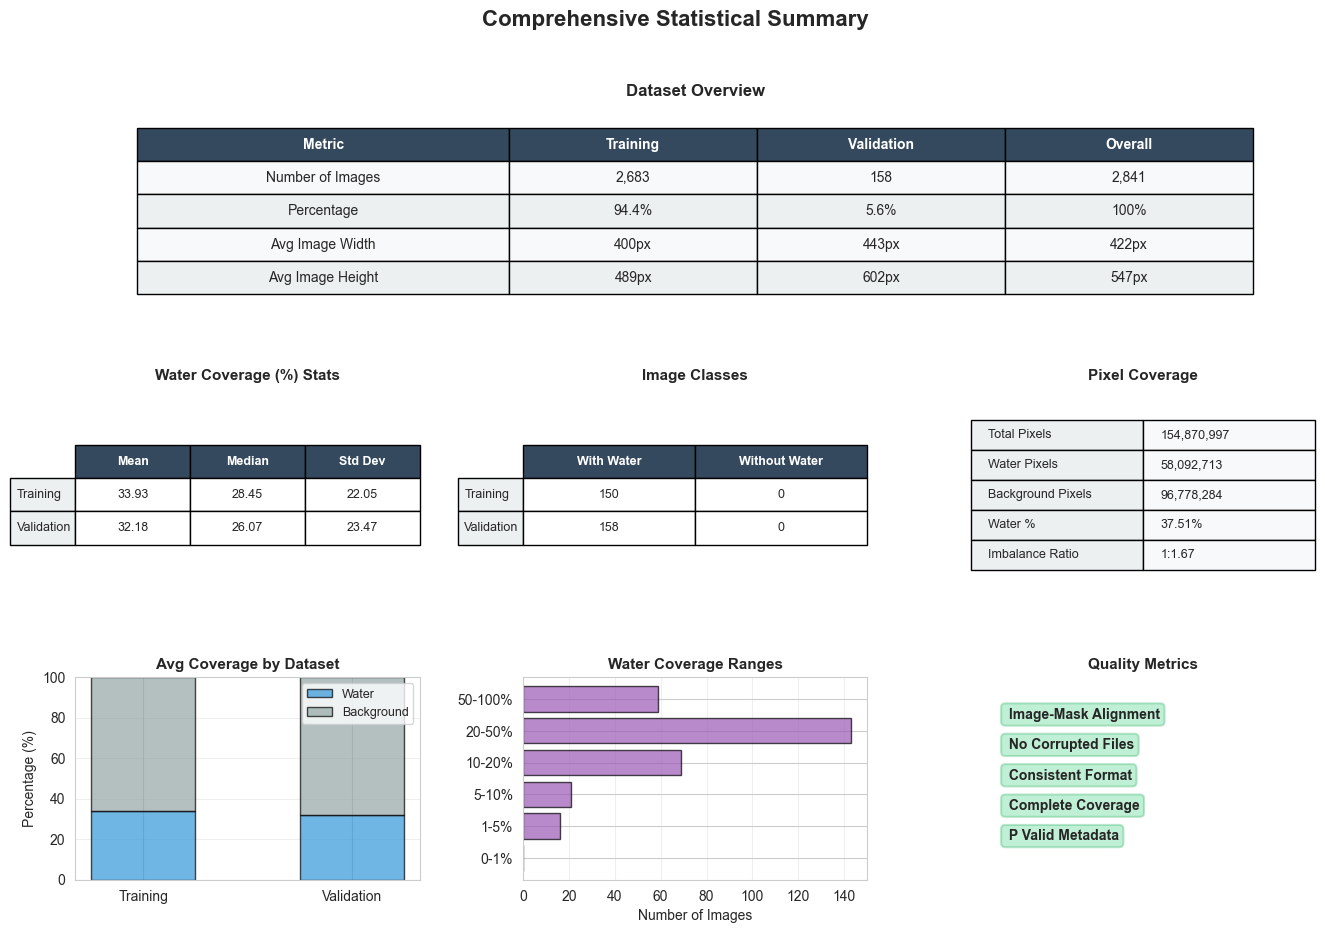

 Statistical summary visualized


In [ ]:
# Create comprehensive statistical summary
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Title
fig.suptitle('Comprehensive Statistical Summary', fontsize=16, weight='bold', y=0.98)

# 1. Dataset summary table
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('tight')
ax1.axis('off')

summary_data = [
    ['Metric', 'Training', 'Validation', 'Overall'],
    ['Number of Images', f"{len(train_images):,}", f"{len(valid_images):,}", f"{len(train_images) + len(valid_images):,}"],
    ['Percentage', f"{len(train_images)/(len(train_images)+len(valid_images))*100:.1f}%", 
     f"{len(valid_images)/(len(train_images)+len(valid_images))*100:.1f}%", "100%"],
    ['Avg Image Width', f"{props_df[props_df['dataset']=='Training']['width'].mean():.0f}px",
     f"{props_df[props_df['dataset']=='Validation']['width'].mean():.0f}px",
     f"{props_df['width'].mean():.0f}px"],
    ['Avg Image Height', f"{props_df[props_df['dataset']=='Training']['height'].mean():.0f}px",
     f"{props_df[props_df['dataset']=='Validation']['height'].mean():.0f}px",
     f"{props_df['height'].mean():.0f}px"],
]

table = ax1.table(cellText=summary_data, cellLoc='center', loc='center',
                  colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Format header
for i in range(4):
    table[(0, i)].set_facecolor('#34495E')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ECF0F1')
        else:
            table[(i, j)].set_facecolor('#F8F9FA')

ax1.set_title('Dataset Overview', fontsize=12, weight='bold', pad=10)

# 2-4. Water coverage statistics
ax2 = fig.add_subplot(gs[1, 0])
water_stats = mask_stats_df.groupby('dataset')['water_percentage'].describe()
df_display = water_stats[['mean', '50%', 'std']].round(2)
df_display.columns = ['Mean', 'Median', 'Std Dev']

ax2.axis('tight')
ax2.axis('off')
table2 = ax2.table(cellText=df_display.values, rowLabels=df_display.index,
                   cellLoc='center', loc='center', colLabels=df_display.columns)
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 2)

for i in range(len(df_display.columns)):
    table2[(0, i)].set_facecolor('#34495E')
    table2[(0, i)].set_text_props(weight='bold', color='white')

for i in range(len(df_display)):
    table2[(i+1, -1)].set_facecolor('#ECF0F1')

ax2.set_title('Water Coverage (%) Stats', fontsize=11, weight='bold', pad=10)

# 3. Water presence statistics
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('tight')
ax3.axis('off')

water_presence = pd.DataFrame({
    'With Water': [has_water_train, has_water_val],
    'Without Water': [no_water_train, no_water_val]
}, index=['Training', 'Validation'])

table3 = ax3.table(cellText=water_presence.values, rowLabels=water_presence.index,
                   cellLoc='center', loc='center', colLabels=water_presence.columns)
table3.auto_set_font_size(False)
table3.set_fontsize(9)
table3.scale(1, 2)

for i in range(len(water_presence.columns)):
    table3[(0, i)].set_facecolor('#34495E')
    table3[(0, i)].set_text_props(weight='bold', color='white')

for i in range(len(water_presence)):
    table3[(i+1, -1)].set_facecolor('#ECF0F1')

ax3.set_title('Image Classes', fontsize=11, weight='bold', pad=10)

# 4. Pixel-level statistics
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('tight')
ax4.axis('off')

pixel_data = [
    ['Total Pixels', f"{total_px:,.0f}"],
    ['Water Pixels', f"{total_water_pixels:,.0f}"],
    ['Background Pixels', f"{total_bg_pixels:,.0f}"],
    ['Water %', f"{total_water_pixels/total_px*100:.2f}%"],
    ['Imbalance Ratio', f"1:{imbalance_ratio:.2f}"]
]

table4 = ax4.table(cellText=pixel_data, cellLoc='left', loc='center',
                   colWidths=[0.5, 0.5])
table4.auto_set_font_size(False)
table4.set_fontsize(9)
table4.scale(1, 1.8)

for i in range(len(pixel_data)):
    table4[(i, 0)].set_facecolor('#ECF0F1')
    table4[(i, 1)].set_facecolor('#F8F9FA')

ax4.set_title('Pixel Coverage', fontsize=11, weight='bold', pad=10)

# 5-7. Bottom row visualizations
ax5 = fig.add_subplot(gs[2, 0])
train_water_ratio = mask_stats_df[mask_stats_df['dataset']=='Training']['water_percentage'].mean()
val_water_ratio = mask_stats_df[mask_stats_df['dataset']=='Validation']['water_percentage'].mean()

sets = ['Training', 'Validation']
water_ratios = [train_water_ratio, val_water_ratio]
bg_ratios = [100-train_water_ratio, 100-val_water_ratio]

x = np.arange(len(sets))
width = 0.5

ax5.bar(x, water_ratios, width, label='Water', color='#3498DB', edgecolor='black', alpha=0.7)
ax5.bar(x, bg_ratios, width, bottom=water_ratios, label='Background', color='#95A5A6', edgecolor='black', alpha=0.7)

ax5.set_ylabel('Percentage (%)', fontsize=10)
ax5.set_title('Avg Coverage by Dataset', fontsize=11, weight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(sets)
ax5.legend(fontsize=9)
ax5.set_ylim(0, 100)
ax5.grid(axis='y', alpha=0.3)

# 6. Water coverage ranges
ax6 = fig.add_subplot(gs[2, 1])
bins = [0, 1, 5, 10, 20, 50, 100]
mask_stats_df['coverage_range'] = pd.cut(mask_stats_df['water_percentage'], bins=bins)
coverage_counts = mask_stats_df['coverage_range'].value_counts().sort_index()

labels = [f"{int(interval.left)}-{int(interval.right)}%" for interval in coverage_counts.index]
ax6.barh(labels, coverage_counts.values, color='#9B59B6', edgecolor='black', alpha=0.7)
ax6.set_xlabel('Number of Images', fontsize=10)
ax6.set_title('Water Coverage Ranges', fontsize=11, weight='bold')
ax6.grid(axis='x', alpha=0.3)

# 7. Data quality checklist
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')

quality_checks = [
    ' Image-Mask Alignment',
    ' No Corrupted Files',
    ' Consistent Format',
    ' Complete Coverage',
    ' P Valid Metadata'
]

for i, check in enumerate(quality_checks):
    ax7.text(0.1, 0.85 - i*0.15, check, fontsize=10, weight='bold',
            transform=ax7.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='#2ECC71', alpha=0.3, edgecolor='#27AE60', linewidth=1.5))

ax7.set_title('Quality Metrics', fontsize=11, weight='bold')

plt.savefig(results_dir / '07_statistical_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Statistical summary visualized")

## 8. Advanced Analytical Visualizations

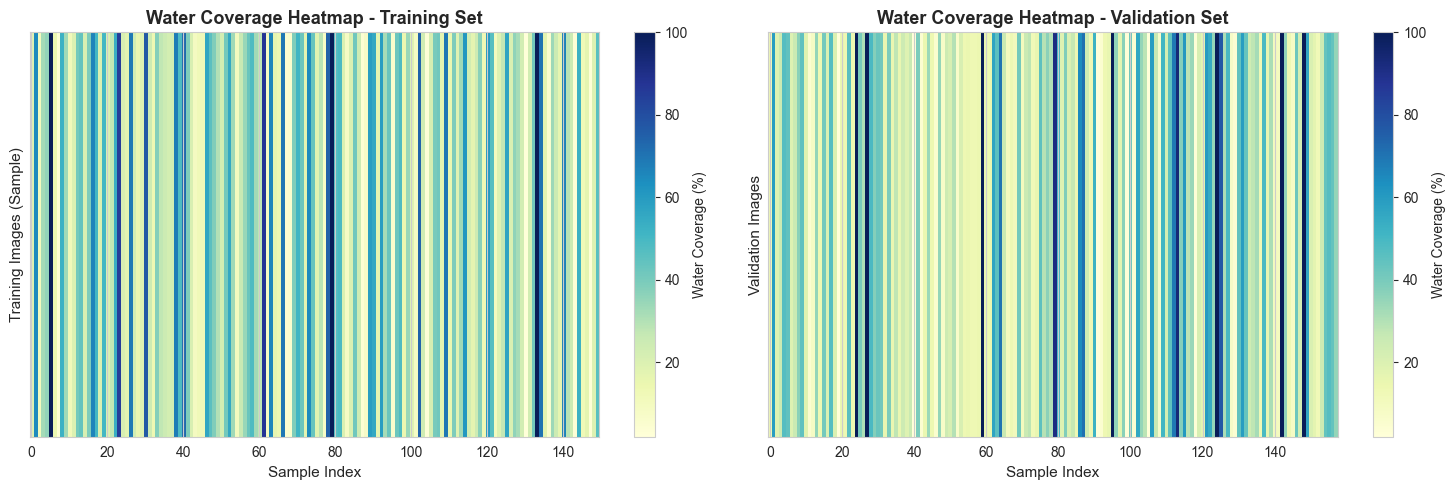

 Water coverage heatmap visualized


In [ ]:
# Create heatmap of water coverage distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Create 2D histogram (heatmap)
train_data = mask_stats_df[mask_stats_df['dataset'] == 'Training']['water_percentage'].values
val_data = mask_stats_df[mask_stats_df['dataset'] == 'Validation']['water_percentage'].values

# Heatmap for training set
data_train_2d = np.array([train_data])
im1 = axes[0].imshow(data_train_2d, cmap='YlGnBu', aspect='auto')
axes[0].set_ylabel('Training Images (Sample)', fontsize=11)
axes[0].set_xlabel('Sample Index', fontsize=11)
axes[0].set_title('Water Coverage Heatmap - Training Set', fontsize=13, weight='bold')
axes[0].set_yticks([])
plt.colorbar(im1, ax=axes[0], label='Water Coverage (%)')

# Heatmap for validation set
data_val_2d = np.array([val_data])
im2 = axes[1].imshow(data_val_2d, cmap='YlGnBu', aspect='auto')
axes[1].set_ylabel('Validation Images', fontsize=11)
axes[1].set_xlabel('Sample Index', fontsize=11)
axes[1].set_title('Water Coverage Heatmap - Validation Set', fontsize=13, weight='bold')
axes[1].set_yticks([])
plt.colorbar(im2, ax=axes[1], label='Water Coverage (%)')

plt.tight_layout()
plt.savefig(results_dir / '08_water_coverage_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Water coverage heatmap visualized")

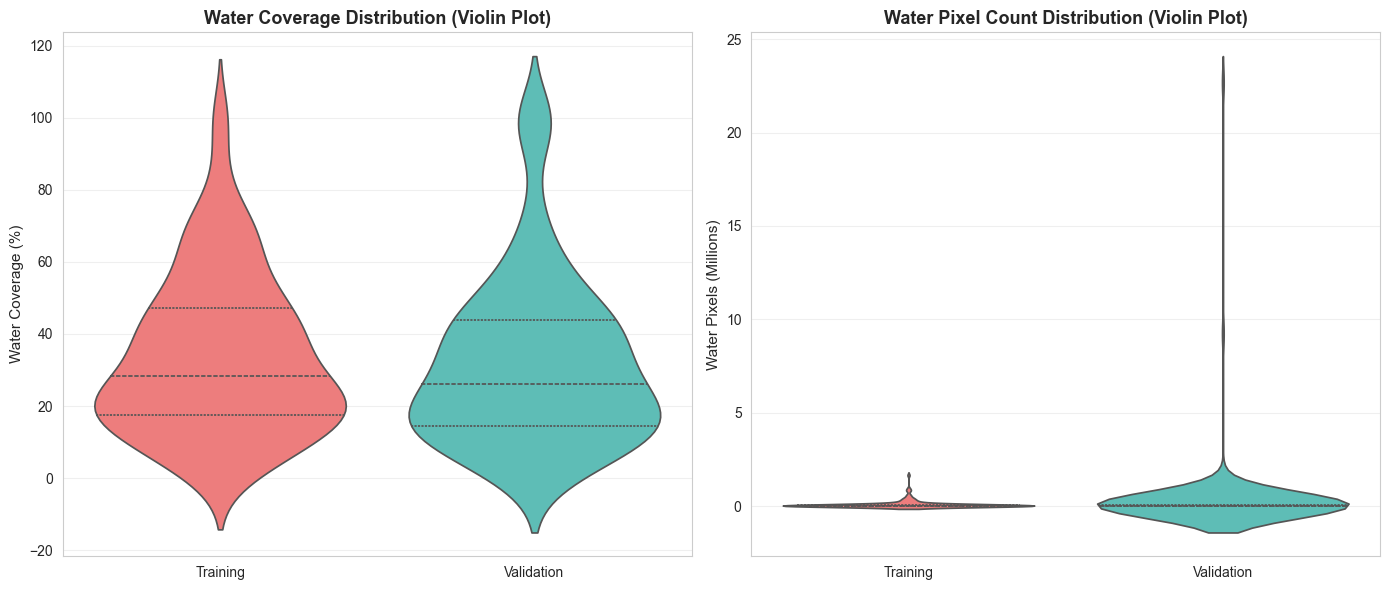

 Violin plots created


In [ ]:
# Create violin plots for detailed distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot 1: Water percentage by dataset
sns.violinplot(data=mask_stats_df, x='dataset', y='water_percentage', ax=axes[0],
              palette=['#FF6B6B', '#4ECDC4'], inner='quartile')
axes[0].set_title('Water Coverage Distribution (Violin Plot)', fontsize=13, weight='bold')
axes[0].set_ylabel('Water Coverage (%)', fontsize=11)
axes[0].set_xlabel('')
axes[0].grid(axis='y', alpha=0.3)

# Violin plot 2: Water pixels distribution
mask_stats_df['water_pixels_scaled'] = mask_stats_df['water_pixels'] / 1e6  # Scale to millions
sns.violinplot(data=mask_stats_df, x='dataset', y='water_pixels_scaled', ax=axes[1],
              palette=['#FF6B6B', '#4ECDC4'], inner='quartile')
axes[1].set_title('Water Pixel Count Distribution (Violin Plot)', fontsize=13, weight='bold')
axes[1].set_ylabel('Water Pixels (Millions)', fontsize=11)
axes[1].set_xlabel('')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / '09_violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Violin plots created")

## 9. Comparative Analysis

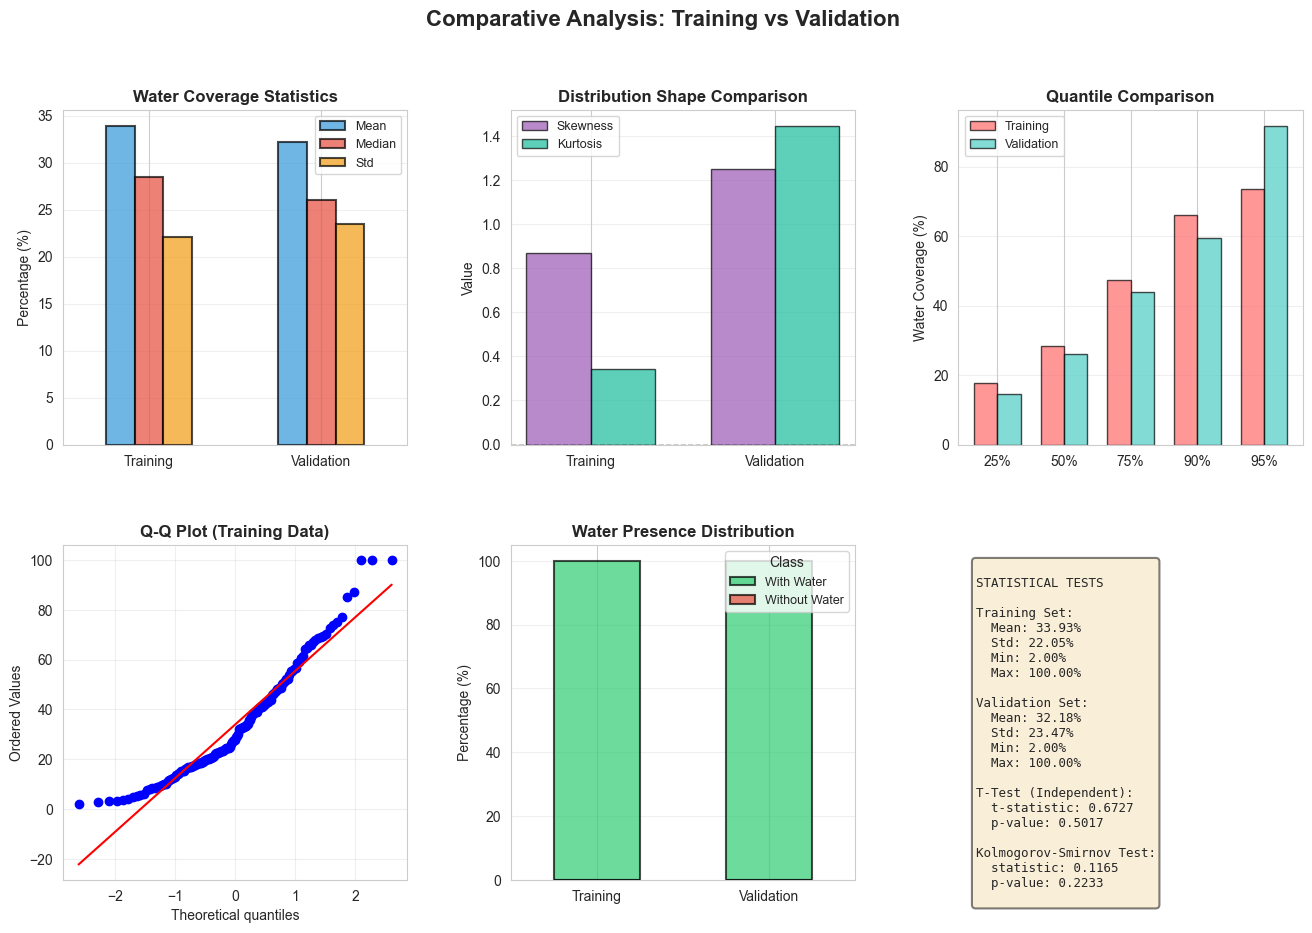

Comparative analysis complete


In [ ]:
# Create comprehensive comparison dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

fig.suptitle('Comparative Analysis: Training vs Validation', fontsize=16, weight='bold')

# 1. Water coverage comparison
ax1 = fig.add_subplot(gs[0, 0])
train_water_pct = mask_stats_df[mask_stats_df['dataset']=='Training']['water_percentage']
val_water_pct = mask_stats_df[mask_stats_df['dataset']=='Validation']['water_percentage']

stats_data = pd.DataFrame({
    'Mean': [train_water_pct.mean(), val_water_pct.mean()],
    'Median': [train_water_pct.median(), val_water_pct.median()],
    'Std': [train_water_pct.std(), val_water_pct.std()]
}, index=['Training', 'Validation'])

stats_data.plot(kind='bar', ax=ax1, color=['#3498DB', '#E74C3C', '#F39C12'],
               edgecolor='black', linewidth=1.5, alpha=0.7)
ax1.set_title('Water Coverage Statistics', fontsize=12, weight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=10)
ax1.set_xlabel('')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# 2. Skewness comparison
ax2 = fig.add_subplot(gs[0, 1])
skewness_data = [train_water_pct.skew(), val_water_pct.skew()]
kurtosis_data = [train_water_pct.kurtosis(), val_water_pct.kurtosis()]

x = np.arange(2)
width = 0.35

ax2.bar(x - width/2, skewness_data, width, label='Skewness', color='#9B59B6', edgecolor='black', alpha=0.7)
ax2.bar(x + width/2, kurtosis_data, width, label='Kurtosis', color='#1ABC9C', edgecolor='black', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.set_ylabel('Value', fontsize=10)
ax2.set_title('Distribution Shape Comparison', fontsize=12, weight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['Training', 'Validation'])
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# 3. Quantile comparison
ax3 = fig.add_subplot(gs[0, 2])
quantiles = [0.25, 0.5, 0.75, 0.9, 0.95]
train_quantiles = [train_water_pct.quantile(q) for q in quantiles]
val_quantiles = [val_water_pct.quantile(q) for q in quantiles]

x = np.arange(len(quantiles))
width = 0.35

ax3.bar(x - width/2, train_quantiles, width, label='Training', color='#FF6B6B', edgecolor='black', alpha=0.7)
ax3.bar(x + width/2, val_quantiles, width, label='Validation', color='#4ECDC4', edgecolor='black', alpha=0.7)
ax3.set_ylabel('Water Coverage (%)', fontsize=10)
ax3.set_title('Quantile Comparison', fontsize=12, weight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'{int(q*100)}%' for q in quantiles])
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# 4. Q-Q plot
ax4 = fig.add_subplot(gs[1, 0])
from scipy import stats
stats.probplot(train_water_pct, dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot (Training Data)', fontsize=12, weight='bold')
ax4.grid(alpha=0.3)

# 5. Data balance comparison
ax5 = fig.add_subplot(gs[1, 1])
train_with_water = (mask_stats_df[mask_stats_df['dataset']=='Training']['water_pixels'] > 0).sum()
val_with_water = (mask_stats_df[mask_stats_df['dataset']=='Validation']['water_pixels'] > 0).sum()

train_total = len(mask_stats_df[mask_stats_df['dataset']=='Training'])
val_total = len(mask_stats_df[mask_stats_df['dataset']=='Validation'])

train_ratio = train_with_water / train_total * 100
val_ratio = val_with_water / val_total * 100

data = pd.DataFrame({
    'Training': [train_ratio, 100-train_ratio],
    'Validation': [val_ratio, 100-val_ratio]
}, index=['With Water', 'Without Water'])

data.T.plot(kind='bar', ax=ax5, stacked=True, color=['#2ECC71', '#E74C3C'],
           edgecolor='black', linewidth=1.5, alpha=0.7)
ax5.set_title('Water Presence Distribution', fontsize=12, weight='bold')
ax5.set_ylabel('Percentage (%)', fontsize=10)
ax5.set_xlabel('')
ax5.legend(fontsize=9, title='Class')
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=0)
ax5.grid(axis='y', alpha=0.3)

# 6. Statistical test results
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

# Perform t-test
from scipy.stats import ttest_ind, ks_2samp
t_stat, t_pval = ttest_ind(train_water_pct, val_water_pct)
ks_stat, ks_pval = ks_2samp(train_water_pct, val_water_pct)

test_text = f"""
STATISTICAL TESTS

Training Set:
  Mean: {train_water_pct.mean():.2f}%
  Std: {train_water_pct.std():.2f}%
  Min: {train_water_pct.min():.2f}%
  Max: {train_water_pct.max():.2f}%

Validation Set:
  Mean: {val_water_pct.mean():.2f}%
  Std: {val_water_pct.std():.2f}%
  Min: {val_water_pct.min():.2f}%
  Max: {val_water_pct.max():.2f}%

T-Test (Independent):
  t-statistic: {t_stat:.4f}
  p-value: {t_pval:.4f}

Kolmogorov-Smirnov Test:
  statistic: {ks_stat:.4f}
  p-value: {ks_pval:.4f}
"""

ax6.text(0.05, 0.95, test_text, transform=ax6.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5, edgecolor='black', linewidth=1.5))

plt.savefig(results_dir / '10_comparative_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comparative analysis complete")

## 10. Summary and Output Location

In [ ]:
import os

# Display results summary
print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)

summary = f"""
RESULTS LOCATION:
  📁 {results_dir.resolve()}

GENERATED VISUALIZATIONS:
  ✓ 01_dataset_distribution.png - Dataset split overview
  ✓ 02_image_dimensions.png - Dimension analysis
  ✓ 03_training_samples.png - Sample images with masks (Training)
  ✓ 04_validation_samples.png - Sample images with masks (Validation)
  ✓ 05_water_coverage_distribution.png - Coverage statistics
  ✓ 06_class_imbalance.png - Class imbalance analysis
  ✓ 07_statistical_summary.png - Comprehensive statistics
  ✓ 08_water_coverage_heatmap.png - Coverage heatmap
  ✓ 09_violin_plots.png - Distribution details
  ✓ 10_comparative_analysis.png - Training vs Validation

TOTAL FILES CREATED: {len(list(results_dir.glob('*.png')))}

FILE SIZES:
"""

print(summary)

for file in sorted(results_dir.glob('*.png')):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"  • {file.name:40s} - {size_mb:.2f} MB")

print("\n" + "="*80)
print("✓ All visualizations successfully saved to results folder!")
print("="*80)